In [1]:
import torch
import sys
from models.forecasting.diffusion import DDPM
from models.unet.unet import UNet
sys.path.append('..')
import yaml
from models.model_utils.noise_scheduler import CosineScheduler
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from datasets.diffusion_dataset import DiffusionDataset
from utils.visualisation_utils import tensor_to_gif

In [2]:
cfg = yaml.safe_load('../configs/training_configs/diffusion_training.yaml')

## Load model

In [3]:
with open("../configs/training_configs/diffusion_training.yaml", "r") as file:
    cfg = yaml.safe_load(file)

# --- Model ---
unet = UNet(
    in_channels=cfg['in_channels'],
    out_channels=cfg['out_channels'],
    kernel_size=cfg['kernel_size'],
    final_filters=cfg['final_filters'],
    encoder_dropout=cfg['encoder_dropout'],
    input_size=cfg['input_size'],
)

noise_schedule = CosineScheduler(T=cfg['num_timesteps'], s=cfg['cosine_shift']).schedule()

diffusion_model = DDPM(
    denoising_model=unet,
    noise_schedule=noise_schedule,
    optimiser=cfg['optimiser'],
    learning_rate=cfg['learning_rate']
)

In [4]:
model_path = '../checkpoints/diffusion_heat/ddpm-epoch=0019-val_loss=0.0000.ckpt'
diffusion_model.load_state_dict(torch.load(model_path)['state_dict'])

<All keys matched successfully>

## Load in test data simulation

In [6]:
test_data_path = '../data/test_data/heat_equation.pt'
test_dataset = DiffusionDataset(test_data_path, field_keys = ['a'], num_timesteps=cfg['num_timesteps'])
test_dataloader = DataLoader(test_dataset, batch_size = 800, shuffle=False)

In [7]:
test_sample = test_dataset.__getitem__(0)
test_input_field = test_sample[0][0]

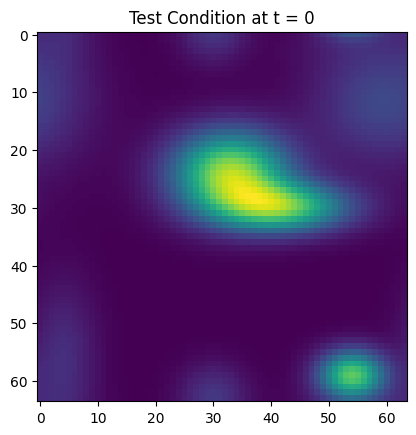

In [8]:
plt.title('Test Condition at t = 0')
plt.imshow(test_input_field.numpy())
plt.show()

## Run inference for one step with model

In [9]:
diffusion_model.eval()
input, label = test_sample[0].unsqueeze(0), test_sample[1]
with torch.no_grad():
    output = diffusion_model(input)

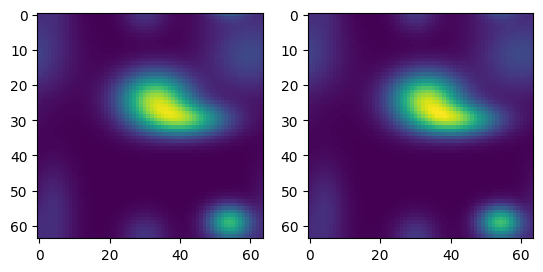

In [10]:
fig, ax = plt.subplots(1, 2)
im = ax[1].imshow(output.squeeze().numpy())                                                                                                
ax[0].imshow(label.numpy(), vmin=im.norm.vmin, vmax=im.norm.vmax)

# Multi-step forecast

In [11]:
num_time_steps = 100
multi_step_output = []
input, label = test_sample[0].unsqueeze(0), test_sample[1]
device = torch.device("mps")
diffusion_model.to(device)

for t in range(num_time_steps):
    with torch.no_grad():
        output = diffusion_model(input.to(device))
        multi_step_output.append(output)
        input[0,0] = output.squeeze()

In [14]:
filename = 'test_output_multistep_forecast.gif'
tensor_to_gif(torch.concat(multi_step_output).squeeze()[::],filename=filename,fps = 10)

In [1]:
import torch
j = torch.load('../data/raw_data/heat_equation_2d/aggregated_2D_heat_sim.pt', mmap=True)